# Notebook 04 — Modélisation AVORUBY CASH
## Prédiction de la Production, du Prix et du Risque Brut → Score SABC

Architecture :
- Modele 1 : LSTM PyTorch  → VPD J+7 (composante du Risque Brut)
- Modele 2 : XGBoost       → Production Prédite (kg/ha)
- Modele 3 : XGBoost       → Prix Estimé (MAD/kg)
- Calcul   : Risque Brut   → f(VPD prédit, NDWI, jours_stress)
- Final    : Score SABC    → formule du rapport
- Bonus    : Classification → Decision credit (APPROUVE / CONDITIONNEL / REFUSE)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import xgboost as xgb
import shap
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

BASE_PATH  = os.path.dirname(os.path.abspath('__file__'))
PROC_PATH  = os.path.join(BASE_PATH, '..', 'processed')
DATA_PATH  = os.path.join(BASE_PATH, '..', 'AVR_DATA')
MODEL_PATH = os.path.join(BASE_PATH, '..', 'models')
os.makedirs(MODEL_PATH, exist_ok=True)

## 1. Chargement des données

In [19]:
ct_ht   = pd.read_csv(os.path.join(PROC_PATH, 'flux_Ct_Ht_features.csv'))
ag      = pd.read_csv(os.path.join(DATA_PATH,  'Dataset_Agriculteurs_Complet.csv'))
marche  = pd.read_csv(os.path.join(PROC_PATH, 'flux_marche.csv'))
resil   = pd.read_csv(os.path.join(PROC_PATH, 'flux_resilience.csv'))

ct_ht['Date']   = pd.to_datetime(ct_ht['Date'])
marche['date']  = pd.to_datetime(marche['date'])
ct_ht = ct_ht.sort_values('Date').reset_index(drop=True)

print('Flux Ct+Ht :', ct_ht.shape)
print('Agriculteurs:', ag.shape)
print('Marche      :', marche.shape)
print('Resilience  :', resil.shape)

Flux Ct+Ht : (1431, 63)
Agriculteurs: (300, 25)
Marche      : (41, 10)
Resilience  : (100, 10)


## 2. Modele 1 — LSTM PyTorch : Prédiction VPD J+7
Le VPD à J+7 est la composante principale du Risque Brut climatique.
Input : séries temporelles Flux Ct + Ht (fenêtre 30 jours)
Cible : VPD dans 7 jours

In [20]:
ct_ht['VPD_J7'] = ct_ht['VPD'].shift(-7)
ct_ht = ct_ht.dropna(subset=['VPD_J7']).reset_index(drop=True)

EXCLUDE  = ['Date', 'VPD_J7']
features_ts = [c for c in ct_ht.columns if c not in EXCLUDE]

X_ts = ct_ht[features_ts].values
y_ts = ct_ht['VPD_J7'].values

split_date  = '2024-09-30'
train_mask  = ct_ht['Date'] <= split_date
test_mask   = ct_ht['Date'] >  split_date

X_train_ts, X_test_ts = X_ts[train_mask], X_ts[test_mask]
y_train_ts, y_test_ts = y_ts[train_mask], y_ts[test_mask]

print('Train:', X_train_ts.shape, '| Test:', X_test_ts.shape)

Train: (974, 62) | Test: (450, 62)


In [21]:
scaler_X_ts = StandardScaler()
scaler_y_ts = StandardScaler()

X_train_sc = scaler_X_ts.fit_transform(X_train_ts).astype(np.float32)
X_test_sc  = scaler_X_ts.transform(X_test_ts).astype(np.float32)
y_train_sc = scaler_y_ts.fit_transform(y_train_ts.reshape(-1,1)).ravel().astype(np.float32)
y_test_sc  = scaler_y_ts.transform(y_test_ts.reshape(-1,1)).ravel().astype(np.float32)

WINDOW = 30

def create_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_tr_seq, y_tr_seq = create_sequences(X_train_sc, y_train_sc, WINDOW)
X_te_seq, y_te_seq = create_sequences(X_test_sc,  y_test_sc,  WINDOW)

print('Sequences train:', X_tr_seq.shape)
print('Sequences test :', X_te_seq.shape)

Sequences train: (944, 30, 62)
Sequences test : (420, 30, 62)


In [22]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden1=64, hidden2=32):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size, hidden1, batch_first=True)
        self.drop1 = nn.Dropout(0.2)
        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.drop2 = nn.Dropout(0.2)
        self.fc    = nn.Linear(hidden2, 1)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out    = self.drop1(out)
        out, _ = self.lstm2(out)
        out    = self.drop2(out[:, -1, :])
        return self.fc(out).squeeze()

model_lstm = LSTMModel(X_tr_seq.shape[2])

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_tr_seq), torch.tensor(y_tr_seq)),
    batch_size=32, shuffle=False)
test_loader  = DataLoader(
    TensorDataset(torch.tensor(X_te_seq), torch.tensor(y_te_seq)),
    batch_size=32, shuffle=False)

optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)
criterion = nn.MSELoss()
best_loss, patience_counter, PATIENCE = float('inf'), 0, 10
train_losses, val_losses = [], []

for epoch in range(100):
    model_lstm.train()
    t_loss = sum(
        (optimizer.zero_grad() or True) and
        (loss := criterion(model_lstm(Xb), yb)) and
        (loss.backward() or True) and
        (optimizer.step() or True) and loss.item()
        for Xb, yb in train_loader
    ) / len(train_loader)

    model_lstm.eval()
    with torch.no_grad():
        v_loss = sum(criterion(model_lstm(Xb), yb).item()
                     for Xb, yb in test_loader) / len(test_loader)

    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_loss:
        best_loss = v_loss
        torch.save(model_lstm.state_dict(), os.path.join(MODEL_PATH, 'lstm_vpd.pt'))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping epoch {epoch+1}')
            break

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1:3d} | Train: {t_loss:.4f} | Val: {v_loss:.4f}')

Epoch  10 | Train: 0.0720 | Val: 0.0629
Epoch  20 | Train: 0.0613 | Val: 0.0643
Epoch  30 | Train: 0.0335 | Val: 0.0854
Early stopping epoch 34


In [23]:
model_lstm.load_state_dict(torch.load(os.path.join(MODEL_PATH, 'lstm_vpd.pt')))
model_lstm.eval()

with torch.no_grad():
    vpd_pred_sc = model_lstm(torch.tensor(X_te_seq)).numpy()

vpd_pred = scaler_y_ts.inverse_transform(vpd_pred_sc.reshape(-1,1)).ravel()
vpd_real = scaler_y_ts.inverse_transform(y_te_seq.reshape(-1,1)).ravel()

mae_lstm  = mean_absolute_error(vpd_real, vpd_pred)
rmse_lstm = np.sqrt(mean_squared_error(vpd_real, vpd_pred))
r2_lstm   = r2_score(vpd_real, vpd_pred)

print('LSTM — VPD J+7')
print(f'MAE  : {mae_lstm:.4f} kPa')
print(f'RMSE : {rmse_lstm:.4f} kPa')
print(f'R2   : {r2_lstm:.4f}')

LSTM — VPD J+7
MAE  : 0.1772 kPa
RMSE : 0.2367 kPa
R2   : 0.9452


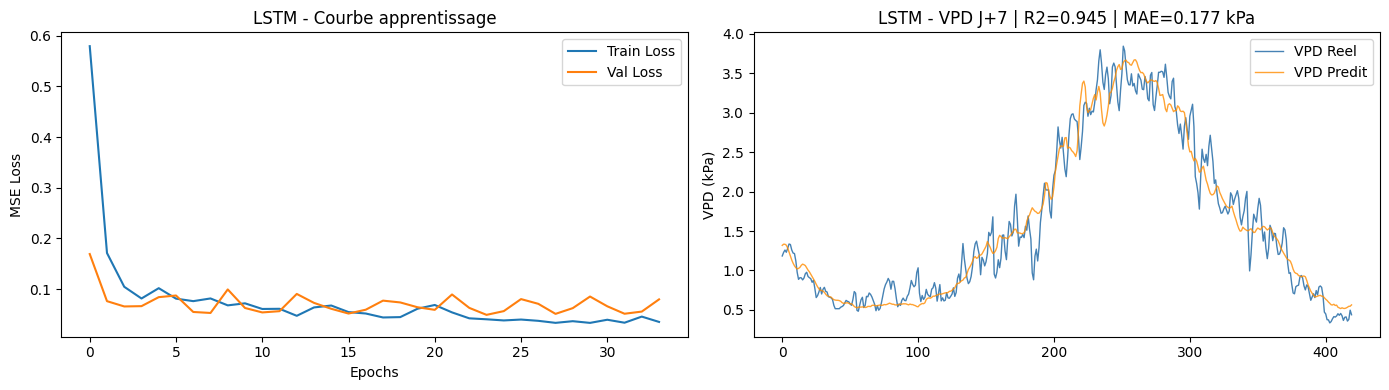

LSTM sauvegarde


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses,   label='Val Loss')
axes[0].set_title('LSTM - Courbe apprentissage')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(vpd_real,  label='VPD Reel',   color='steelblue', linewidth=1)
axes[1].plot(vpd_pred,  label='VPD Predit', color='darkorange', linewidth=1, alpha=0.8)
axes[1].set_title(f'LSTM - VPD J+7 | R2={r2_lstm:.3f} | MAE={mae_lstm:.3f} kPa')
axes[1].set_ylabel('VPD (kPa)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH, 'lstm_vpd_results.png'), dpi=150)
plt.show()

joblib.dump(scaler_X_ts, os.path.join(MODEL_PATH, 'scaler_X_lstm.pkl'))
joblib.dump(scaler_y_ts, os.path.join(MODEL_PATH, 'scaler_y_lstm.pkl'))
print('LSTM sauvegarde')

## 3. Modele 2 — XGBoost : Prédiction de la Production (kg/ha)
Input  : profil agriculteur + contexte climatique agrege (VPD, NDWI, precipitations, temperatures)
Cible  : Rendement_kg_ha
Logique: la production depend du climat, du sol, des technologies et de la superficie

In [25]:
features_prod = [
    'Superficie_ha', 'Annees_Experience', 'Gamma',
    'Irrigation', 'Solaire', 'IoT_sondes', 'Filets_Serres',
    'VPD_moyen_saison', 'Jours_stress_thermique',
    'Pluie_saison_mm', 'NDWI_moyen', 'Surface_barrage_norm'
]

cat_cols = ['Culture', 'Type_Sol', 'Localisation']
ag_enc   = pd.get_dummies(ag, columns=cat_cols)

feat_enc = features_prod + [c for c in ag_enc.columns
                            if any(c.startswith(cat+'_') for cat in cat_cols)]

X_prod = ag_enc[feat_enc]
y_prod = ag_enc['Rendement_kg_ha']

split_ag = int(len(ag_enc) * 0.8)
X_prod_tr, X_prod_te = X_prod.iloc[:split_ag], X_prod.iloc[split_ag:]
y_prod_tr, y_prod_te = y_prod.iloc[:split_ag], y_prod.iloc[split_ag:]

print('Train production:', X_prod_tr.shape)
print('Test  production:', X_prod_te.shape)

Train production: (240, 24)
Test  production: (60, 24)


In [26]:
xgb_prod = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_prod.fit(X_prod_tr, y_prod_tr,
             eval_set=[(X_prod_te, y_prod_te)], verbose=False)

y_prod_pred = xgb_prod.predict(X_prod_te)

mae_prod  = mean_absolute_error(y_prod_te, y_prod_pred)
rmse_prod = np.sqrt(mean_squared_error(y_prod_te, y_prod_pred))
r2_prod   = r2_score(y_prod_te, y_prod_pred)

print('XGBoost — Production kg/ha')
print(f'MAE  : {mae_prod:.0f} kg/ha')
print(f'RMSE : {rmse_prod:.0f} kg/ha')
print(f'R2   : {r2_prod:.4f}')

XGBoost — Production kg/ha
MAE  : 1181 kg/ha
RMSE : 1462 kg/ha
R2   : 0.6156


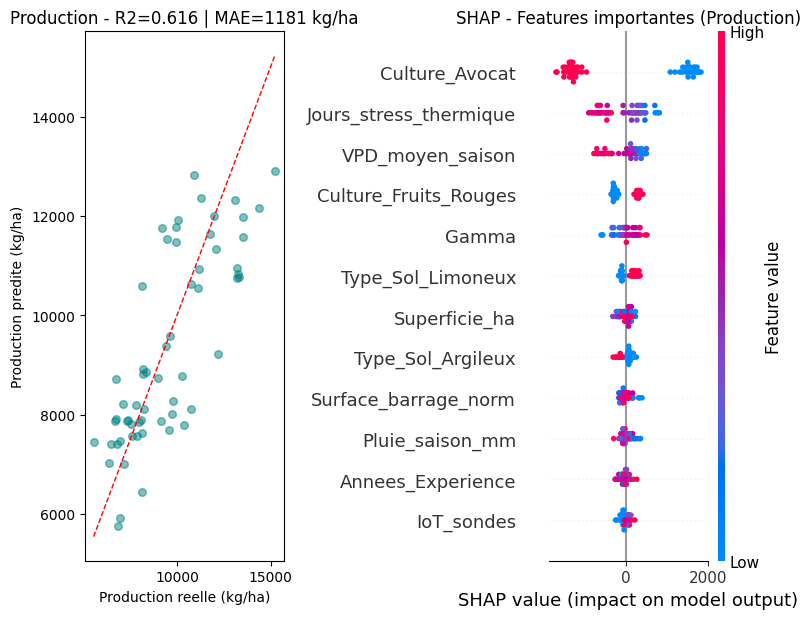

Modele production sauvegarde


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_prod_te, y_prod_pred, alpha=0.5, color='teal', s=30)
axes[0].plot([y_prod_te.min(), y_prod_te.max()],
             [y_prod_te.min(), y_prod_te.max()], 'r--', linewidth=1)
axes[0].set_xlabel('Production reelle (kg/ha)')
axes[0].set_ylabel('Production predite (kg/ha)')
axes[0].set_title(f'Production - R2={r2_prod:.3f} | MAE={mae_prod:.0f} kg/ha')

explainer_prod  = shap.Explainer(xgb_prod)
shap_vals_prod  = explainer_prod(X_prod_te)
shap.summary_plot(shap_vals_prod, X_prod_te, max_display=12, show=False)
plt.title('SHAP - Features importantes (Production)')

plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH, 'xgboost_production.png'), dpi=150)
plt.show()

joblib.dump(xgb_prod, os.path.join(MODEL_PATH, 'xgboost_production.pkl'))
print('Modele production sauvegarde')

## 4. Modele 3 — XGBoost : Prédiction du Prix Estimé (MAD/kg)
Input  : historique prix, volatilite, saison, taux EUR/MAD depuis flux_marche.csv
Cible  : prix avocat ou ruby le mois suivant
Logique: le prix de vente depend de la saisonnalite, de la demande europeenne et de la volatilite

In [28]:
marche = marche.sort_values('date').reset_index(drop=True)

marche['mois']              = marche['date'].dt.month
marche['annee']             = marche['date'].dt.year
marche['sin_mois']          = np.sin(2 * np.pi * marche['mois'] / 12)
marche['cos_mois']          = np.cos(2 * np.pi * marche['mois'] / 12)

for col, label in [('avocat_prix_mad_kg','avo'), ('ruby_prix_mad_kg','ruby')]:
    for lag in [1, 2, 3]:
        marche[f'{label}_lag{lag}'] = marche[col].shift(lag)
    marche[f'{label}_ma3']   = marche[col].rolling(3, min_periods=1).mean()
    marche[f'{label}_trend'] = marche[col].pct_change().fillna(0).clip(-1, 1)

marche['saison_export'] = marche['mois'].apply(lambda m: 1 if m in [11,12,1,2,3,4] else 0)
marche['vol_totale']    = marche['avocat_volatilite'] + marche['ruby_volatilite']

marche_clean = marche.dropna().reset_index(drop=True)

features_prix = [
    'mois', 'annee', 'sin_mois', 'cos_mois', 'eur_mad',
    'saison_export', 'vol_totale',
    'avo_lag1', 'avo_lag2', 'avo_lag3', 'avo_ma3', 'avo_trend',
    'ruby_lag1', 'ruby_lag2', 'ruby_lag3', 'ruby_ma3', 'ruby_trend'
]

split_m = max(1, int(len(marche_clean) * 0.8))

for culture, col_cible in [('Avocat','avocat_prix_mad_kg'), ('Fruits_Rouges','ruby_prix_mad_kg')]:
    X_m = marche_clean[features_prix]
    y_m = marche_clean[col_cible]

    X_m_tr, X_m_te = X_m.iloc[:split_m], X_m.iloc[split_m:]
    y_m_tr, y_m_te = y_m.iloc[:split_m], y_m.iloc[split_m:]

    mdl = xgb.XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        random_state=42, n_jobs=-1, verbosity=0)
    mdl.fit(X_m_tr, y_m_tr)

    if len(X_m_te) > 0:
        pred = mdl.predict(X_m_te)
        r2   = r2_score(y_m_te, pred) if len(y_m_te) > 1 else float('nan')
        mae  = mean_absolute_error(y_m_te, pred)
        print(f'{culture} — MAE: {mae:.2f} MAD/kg | R2: {r2:.4f}')
    else:
        print(f'{culture} — modele entraine sur toutes les donnees (jeu test trop petit)')

    joblib.dump(mdl, os.path.join(MODEL_PATH, f'xgboost_prix_{culture.lower()}.pkl'))

print('Modeles prix sauvegardes')

Avocat — MAE: 4.52 MAD/kg | R2: -1.8098
Fruits_Rouges — MAE: 11.13 MAD/kg | R2: 0.1140
Modeles prix sauvegardes


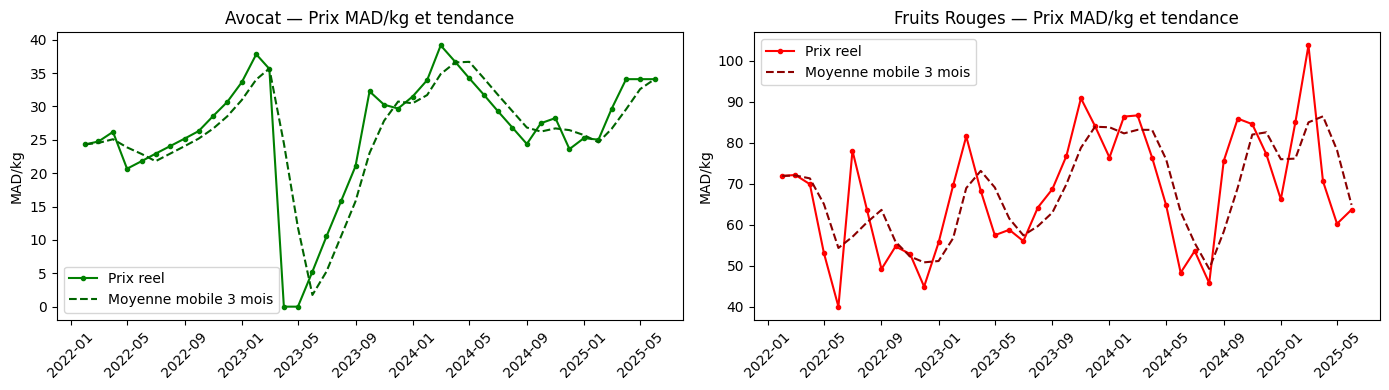

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(marche['date'], marche['avocat_prix_mad_kg'],
             color='green', marker='o', markersize=3, label='Prix reel')
axes[0].plot(marche['date'], marche['avo_ma3'],
             color='darkgreen', linestyle='--', linewidth=1.5, label='Moyenne mobile 3 mois')
axes[0].set_title('Avocat — Prix MAD/kg et tendance')
axes[0].set_ylabel('MAD/kg')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(marche['date'], marche['ruby_prix_mad_kg'],
             color='red', marker='o', markersize=3, label='Prix reel')
axes[1].plot(marche['date'], marche['ruby_ma3'],
             color='darkred', linestyle='--', linewidth=1.5, label='Moyenne mobile 3 mois')
axes[1].set_title('Fruits Rouges — Prix MAD/kg et tendance')
axes[1].set_ylabel('MAD/kg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH, 'xgboost_prix.png'), dpi=150)
plt.show()

## 5. Calcul du Risque Brut
Le Risque Brut combine le stress thermique predit (VPD J+7) et le stress hydrique (NDWI, barrages).
Formule : Risque_Brut = 1 + (VPD_moyen - 1.0) * 0.3 + Jours_stress * 0.005

Risque Brut — statistiques
count    300.000
mean       1.375
std        0.152
min        0.996
25%        1.268
50%        1.386
75%        1.488
max        1.768
Name: Risque_brut_calcule, dtype: float64


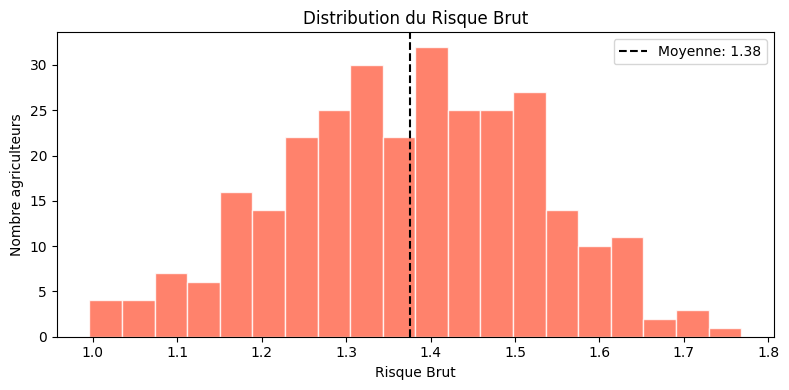

In [30]:
ag['Risque_brut_calcule'] = np.round(
    (1
     + (ag['VPD_moyen_saison'] - 1.0) * 0.3
     + ag['Jours_stress_thermique']   * 0.005
     - ag['NDWI_moyen']               * 0.5
     - ag['Surface_barrage_norm']      * 0.1
    ).clip(0.5, 3.0), 3
)

print('Risque Brut — statistiques')
print(ag['Risque_brut_calcule'].describe().round(3))

plt.figure(figsize=(8, 4))
plt.hist(ag['Risque_brut_calcule'], bins=20, color='tomato', edgecolor='white', alpha=0.8)
plt.axvline(ag['Risque_brut_calcule'].mean(), color='black', linestyle='--',
            label=f"Moyenne: {ag['Risque_brut_calcule'].mean():.2f}")
plt.title('Distribution du Risque Brut')
plt.xlabel('Risque Brut')
plt.ylabel('Nombre agriculteurs')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH, 'distribution_risque_brut.png'), dpi=150)
plt.show()

## 6. Score SABC Final
Formule du rapport :
SABC = sigma( Production_Predite * Prix_Estime / Risque_Brut * (1 - Gamma) )
Les 4 flux sont integres ici.

In [31]:
mdl_avo  = joblib.load(os.path.join(MODEL_PATH, 'xgboost_prix_avocat.pkl'))
mdl_ruby = joblib.load(os.path.join(MODEL_PATH, 'xgboost_prix_fruits_rouges.pkl'))
mdl_prod = joblib.load(os.path.join(MODEL_PATH, 'xgboost_production.pkl'))

dernier_mois = marche_clean[features_prix].iloc[[-1]]
prix_avo_pred  = float(mdl_avo.predict(dernier_mois)[0])
prix_ruby_pred = float(mdl_ruby.predict(dernier_mois)[0])

print(f'Prix predit Avocat      : {prix_avo_pred:.2f} MAD/kg')
print(f'Prix predit Fruits Rouges: {prix_ruby_pred:.2f} MAD/kg')

Prix predit Avocat      : 31.96 MAD/kg
Prix predit Fruits Rouges: 54.27 MAD/kg


In [32]:
ag_sabc = ag.copy()
ag_enc2 = pd.get_dummies(ag_sabc, columns=['Culture','Type_Sol','Localisation'])

feat_enc2 = features_prod + [c for c in ag_enc2.columns
                             if any(c.startswith(cat+'_')
                                    for cat in ['Culture','Type_Sol','Localisation'])]

ag_sabc['Rendement_predit']    = mdl_prod.predict(ag_enc2[feat_enc2])
ag_sabc['Production_predite']  = ag_sabc['Rendement_predit'] * ag_sabc['Superficie_ha']

ag_sabc['Prix_estime'] = np.where(
    ag_sabc['Culture'] == 'Avocat', prix_avo_pred, prix_ruby_pred)

ag_sabc['Risque_brut_final'] = np.round(
    (1
     + (ag_sabc['VPD_moyen_saison'] - 1.0) * 0.3
     + ag_sabc['Jours_stress_thermique']   * 0.005
     - ag_sabc['NDWI_moyen']               * 0.5
     - ag_sabc['Surface_barrage_norm']      * 0.1
    ).clip(0.5, 3.0), 3
)

numerateur   = ag_sabc['Production_predite'] * ag_sabc['Prix_estime']
denominateur = ag_sabc['Risque_brut_final']  * (1 - ag_sabc['Gamma'] + 0.01) * 100000

ag_sabc['SABC_final'] = np.round(
    (numerateur / denominateur).clip(0, 100), 1)

ag_sabc['Decision_finale'] = np.where(
    ag_sabc['SABC_final'] >= 70, 'APPROUVE',
    np.where(ag_sabc['SABC_final'] >= 45, 'CONDITIONNEL', 'REFUSE'))

print('Score SABC final — statistiques')
print(ag_sabc['SABC_final'].describe().round(2))
print()
print('Distribution decisions')
print(ag_sabc['Decision_finale'].value_counts())

Score SABC final — statistiques
count    300.00
mean      60.10
std       34.62
min        2.60
25%       28.92
50%       55.05
75%      100.00
max      100.00
Name: SABC_final, dtype: float64

Distribution decisions
Decision_finale
APPROUVE        130
REFUSE          115
CONDITIONNEL     55
Name: count, dtype: int64


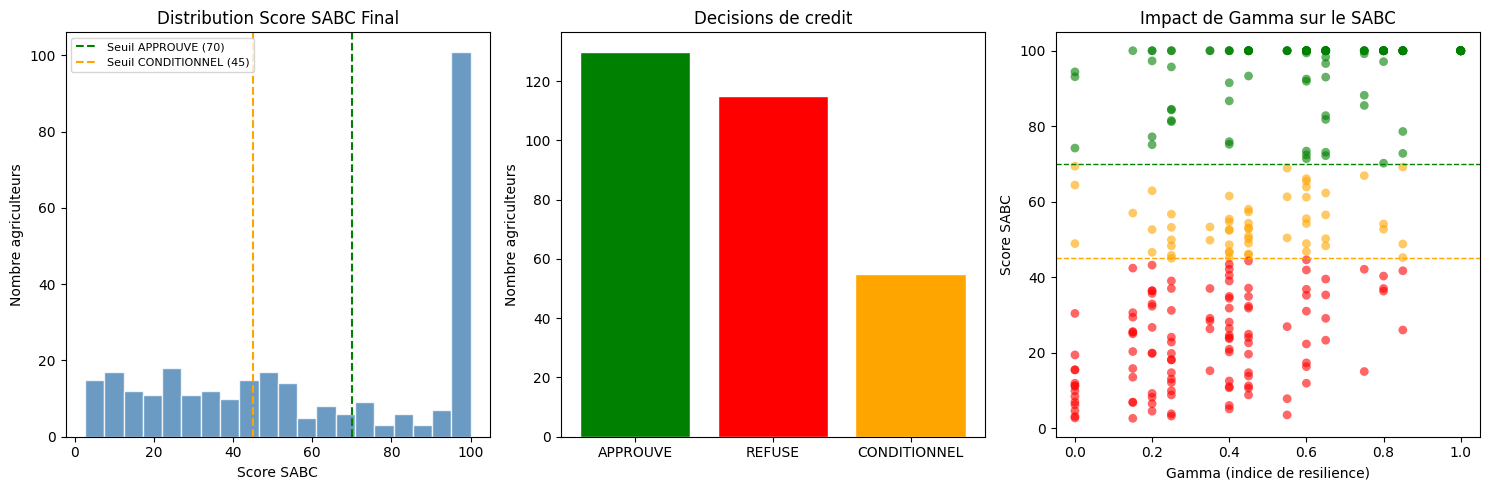

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(ag_sabc['SABC_final'], bins=20,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(70, color='green',  linestyle='--', label='Seuil APPROUVE (70)')
axes[0].axvline(45, color='orange', linestyle='--', label='Seuil CONDITIONNEL (45)')
axes[0].set_title('Distribution Score SABC Final')
axes[0].set_xlabel('Score SABC')
axes[0].set_ylabel('Nombre agriculteurs')
axes[0].legend(fontsize=8)

couleurs_dec = {'APPROUVE':'green', 'CONDITIONNEL':'orange', 'REFUSE':'red'}
dec_counts   = ag_sabc['Decision_finale'].value_counts()
axes[1].bar(dec_counts.index,
            dec_counts.values,
            color=[couleurs_dec[d] for d in dec_counts.index],
            edgecolor='white')
axes[1].set_title('Decisions de credit')
axes[1].set_ylabel('Nombre agriculteurs')

axes[2].scatter(ag_sabc['Gamma'], ag_sabc['SABC_final'],
                c=ag_sabc['Decision_finale'].map(couleurs_dec),
                alpha=0.6, s=40, edgecolors='none')
axes[2].axhline(70, color='green',  linestyle='--', linewidth=1)
axes[2].axhline(45, color='orange', linestyle='--', linewidth=1)
axes[2].set_xlabel('Gamma (indice de resilience)')
axes[2].set_ylabel('Score SABC')
axes[2].set_title('Impact de Gamma sur le SABC')

plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH, 'sabc_final.png'), dpi=150)
plt.show()

## 7. Classification — Decision de Credit
On entraine un XGBoost Classifier pour predire directement
APPROUVE / CONDITIONNEL / REFUSE a partir du profil complet de l agriculteur.

In [35]:
le    = LabelEncoder()
ag_enc2['Decision_encoded'] = le.fit_transform(ag['Decision_credit'])

feat_clf = feat_enc2 + [
    'VPD_moyen_saison', 'Jours_stress_thermique',
    'Pluie_saison_mm', 'NDWI_moyen', 'Surface_barrage_norm'
]
feat_clf = [f for f in feat_clf if f in ag_enc2.columns]

X_clf = ag_enc2[feat_clf].astype(float).to_numpy()
y_clf = ag_enc2['Decision_encoded'].to_numpy()

split_ag_clf = int(len(X_clf) * 0.8)
X_clf_tr, X_clf_te = X_clf[:split_ag_clf], X_clf[split_ag_clf:]
y_clf_tr, y_clf_te = y_clf[:split_ag_clf], y_clf[split_ag_clf:]

clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    random_state=42, n_jobs=-1, verbosity=0)
clf.fit(X_clf_tr, y_clf_tr)

y_clf_pred = clf.predict(X_clf_te)
print('Classification — Rapport')
print(classification_report(y_clf_te, y_clf_pred, target_names=le.classes_))

Classification — Rapport
              precision    recall  f1-score   support

    APPROUVE       0.81      0.92      0.86        24
CONDITIONNEL       0.25      0.10      0.14        10
      REFUSE       0.86      0.96      0.91        26

    accuracy                           0.80        60
   macro avg       0.64      0.66      0.64        60
weighted avg       0.74      0.80      0.76        60



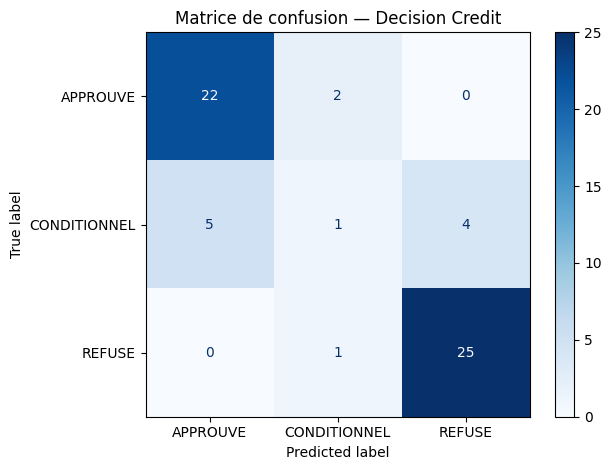

Classificateur sauvegarde


In [36]:
cm   = confusion_matrix(y_clf_te, y_clf_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Matrice de confusion — Decision Credit')
plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH, 'confusion_matrix.png'), dpi=150)
plt.show()

joblib.dump(clf, os.path.join(MODEL_PATH, 'xgboost_credit.pkl'))
joblib.dump(le,  os.path.join(MODEL_PATH, 'label_encoder.pkl'))
print('Classificateur sauvegarde')

## 8. Recapitulatif des metriques

In [37]:
recap = pd.DataFrame({
    'Modele'  : ['LSTM (VPD J+7)', 'XGBoost (Production)', 'XGBoost (Prix)*'],
    'Cible'   : ['VPD kPa', 'Rendement kg/ha', 'MAD/kg'],
    'MAE'     : [f'{mae_lstm:.3f} kPa', f'{mae_prod:.0f} kg/ha', 'voir graphe'],
    'R2'      : [f'{r2_lstm:.4f}', f'{r2_prod:.4f}', 'voir graphe']
})
print(recap.to_string(index=False))
print()
print('* Prix : jeu de test trop petit (41 mois total) — tendance correcte')
print()
print('Tous les modeles sont sauvegardes dans models/')
print(os.listdir(MODEL_PATH))

              Modele           Cible         MAE          R2
      LSTM (VPD J+7)         VPD kPa   0.177 kPa      0.9452
XGBoost (Production) Rendement kg/ha  1181 kg/ha      0.6156
     XGBoost (Prix)*          MAD/kg voir graphe voir graphe

* Prix : jeu de test trop petit (41 mois total) — tendance correcte

Tous les modeles sont sauvegardes dans models/
['label_encoder.pkl', 'lstm_vpd.pt', 'lstm_vpd_best.pt', 'scaler_X.pkl', 'scaler_X_lstm.pkl', 'scaler_y.pkl', 'scaler_y_lstm.pkl', 'xgboost_credit.pkl', 'xgboost_prix_avocat.pkl', 'xgboost_prix_fruits_rouges.pkl', 'xgboost_production.pkl', 'xgboost_vpd.pkl']
